In [27]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

In [ ]:
#data = pd.read_csv("random_reversal_data_200_timeseries.csv")
data = pd.read_csv("random_dataset.csv")
full_run = pd.read_csv("full_data.csv")
covariance_run = pd.read_csv("random_dataset_with_covariance.csv")
withR_run = pd.read_csv("random_dataset_withR.csv")
data.head()
full_run.head()
covariance_run.head()
withR_run.head()

,id,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list
0,0,"[0.0015279107886346914, -0.002397309576809409,...","[-0.7996053768928797, -0.7988133504515464, -0....","[-0.003482169940758633, -0.0033697588914901036...","[-0.9399107369502907, -1.291641465063706, -1.6...","[0.3185123378655262, 0.3192016928489171, 0.321...","[-0.18014417187653378, 0.2735238524695109, 0.3...","[2.3345113780262845e-06, 5.747093207062108e-06...","[0.6393687587560042, 0.6381027688596251, 0.353...","[1.2125507496322982e-05, 1.1355274986776612e-0...","[0.8834321934344386, 1.668337674271917, 2.6647...","[-0.0012217256820049394, 0.0019150028951207029...","[-0.0014360997553399327, 0.0030964644540013584...","[0.0027843618078853636, 0.0026918083903250986,...","[0.7515576790648015, 1.0317804462896831, 0.970...","[0.003272928915204597, 0.004352520311515728, 0..."
1,1,"[-0.014943217384205065, -0.015693549565365516,...","[4.33772932469289, 6.720328607224912, 8.772920...","[-6.410120098836351e-05, -0.000418161142887340...","[5.856857095398363, 5.3295822057695394, 4.5803...","[0.43496770687048525, 0.43599322871637786, 0.4...","[0.032432657608039275, 0.2221964489255154, 0.3...","[0.00022329974579160847, 0.0002462874979605841...","[18.815895694300636, 45.16281658908553, 76.964...","[4.108963968150576e-09, 1.74858741420847e-07, ...","[34.302775035918145, 28.40444648805531, 20.979...","[-0.06481963225272688, -0.10546581009302797, -...","[-0.0875202887647616, -0.08364006250893434, -0...","[-0.0002780536592752573, -0.002810180290975660...","[25.4054607732451, 35.816543761989884, 40.1829...","[-0.0003754315738322534, -0.002228624186276625..."
2,2,"[0.00361197266712009, 0.0011692602006559798, 0...","[3.1129153913786514, 2.6776087422839048, 2.018...","[0.0005904239658739296, 0.0008393369694866559,...","[-3.6394814857949536, -3.7205283659392356, -3....","[0.3742533691428173, 0.37409455439817674, 0.37...","[0.07220723071126094, 0.03322919163454971, 0.1...","[1.3046346548022616e-05, 1.367169416838062e-06...","[9.690242233882103, 7.169588576755195, 4.07551...","[3.4860045947829924e-07, 7.044865483470435e-07...","[13.245825485444243, 13.84233132175848, 13.980...","[0.011243765308717126, 0.003130821335281084, 0...","[-0.013145707649180986, -0.004350265743704375,...","[0.001837939850807779, 0.0022474160072195487, ...","[-11.329397933768753, -9.962119278554148, -7.5...","[-0.0021488370925677983, -0.003122777003556578..."
3,3,"[-0.008051223449080994, -0.0059059512345554, -...","[-0.8870628837732343, -0.06454365641883761, 0....","[-0.0010001784729343245, -0.000975677872082093...","[-0.10396566455706929, -0.21198301277109924, -...","[0.10383722813843602, 0.10594506731682592, 0.1...","[0.2726538530198405, 0.1951050760711771, 0.171...","[6.482219902703167e-05, 3.488025998494645e-05,...","[0.7868805597680866, 0.0041658835839129575, 0....","[1.0003569777212374e-06, 9.519473100706419e-07...","[0.010808859406793055, 0.04493679770351202, 0....","[0.007141941490644473, 0.0003811916873095535, ...","[0.0008370507963811651, 0.0012519613359802467,...","[0.0008872212004890316, 6.297381735112924e-05,...","[0.09222408221539462, 0.013682158742927894, -0...","[0.00010398421961429178, 0.0002068271348180573..."
4,4,"[0.012035932253555256, 0.007087826428881881, 0...","[10.53002990577257, 9.051307260651006, 7.78839...","[-0.0014184941634751732, -0.001169494513384203...","[-3.302247114064573, -3.5983073435357213, -3.8...","[0.09599384790770996, 0.09129865826863173, 0.0...","[-0.5780688190325293, -0.28066193744120255, -0...","[0.0001448636652121717, 5.023728348595648e-05,...","[110.88152981646469, 81.92616312671362, 60.659...","[2.0121256918131316e-06, 1.3677174168357544e-0...","[10.9048360023478, 12.947815738543099, 14.6778...","[0.12673872657378948, 0.06415409481797266, 0.0...","[-0.03974562254937956, -0.025504177888752238, ...","[-0.01493678596255742

## Check shape

In [29]:
print(data.shape)

psi_e = data["psi_e"].tolist()
psi_e_arrays = [ast.literal_eval(x) for x in psi_e]
print(np.array(psi_e_arrays).shape)

#200 timeseries, 8 variables, 1000 timesteps (500 before and after reversal)

(200, 8)
(200, 1000)


## Averages

In [30]:
### Checking Ensemble Averages

## Psi_e
#print(data.head())
psi_e = data["psi_e"].tolist()

#make it into an array of arrays
psi_e_arrays = [ast.literal_eval(x) for x in psi_e]
psi_e_arrays = np.array(psi_e_arrays)

#take mean by timestep
psi_e_means_by_timestep = np.mean(psi_e_arrays, axis = 0)
psi_e_means_by_timestep = np.array(psi_e_means_by_timestep)

#########################################
## b_e
b_e = data["b_e"].tolist()

#make it into an array of arrays
b_e_arrays = [ast.literal_eval(x) for x in b_e]
b_e_arrays = np.array(b_e_arrays)

#take mean by timestep
b_e_means_by_timestep = np.mean(b_e_arrays, axis = 0)
b_e_means_by_timestep = np.array(b_e_means_by_timestep)

#########################################
## psi_plus
psi_plus = data["psi_plus"].tolist()

#make it into an array of arrays
psi_plus_arrays = [ast.literal_eval(x) for x in psi_plus]
psi_plus_arrays = np.array(psi_plus_arrays)

#take mean by timestep
psi_plus_means_by_timestep = np.mean(psi_plus_arrays, axis = 0)
psi_plus_means_by_timestep = np.array(psi_plus_means_by_timestep)

#########################################
## b_plus
b_plus = data["b_plus"].tolist()

#make it into an array of arrays
b_plus_arrays = [ast.literal_eval(x) for x in b_plus]
b_plus_arrays = np.array(b_plus_arrays)

#take mean by timestep
b_plus_means_by_timestep = np.mean(b_plus_arrays, axis = 0)
b_plus_means_by_timestep = np.array(b_plus_means_by_timestep)

#########################################
## Now let's check U
u_data = data["u_list"].tolist()

#make it into an array of arrays
u_arrays = [ast.literal_eval(x) for x in u_data]
u_arrays = np.array(u_arrays)

#take mean by timestep
u_means_by_timestep = np.mean(u_arrays, axis = 0)
u_means_by_timestep = np.array(u_means_by_timestep)


#################
## Now let's check R and U
r_data = withR_run["r_list"].tolist()
u_data2 = withR_run["u_list"].tolist()

#make it into an array of arrays
r_arrays = [ast.literal_eval(x) for x in r_data]
r_arrays = np.array(r_arrays)
u_arrays2 = [ast.literal_eval(x) for x in u_data2]
u_arrays2 = np.array(u_arrays2)

#take mean by timestep
r_means_by_timestep = np.mean(r_arrays, axis = 0)
r_means_by_timestep = np.array(r_means_by_timestep)
u_means_by_timestep2 = np.mean(u_arrays2, axis = 0)
u_means_by_timestep2 = np.array(u_means_by_timestep2)


##
print(np.quantile(psi_e_means_by_timestep, 0.75))
print(np.quantile(b_e_means_by_timestep, 0.75))
print(np.quantile(psi_plus_means_by_timestep, 0.75))
print(np.quantile(b_plus_means_by_timestep, 0.75))
print(np.quantile(u_means_by_timestep, 0.75))

0.0005617186129133025
0.5270579433537281
0.00026245637206676574
0.25015713048148086
0.3499245066521609


In [31]:
#full data averages

##psi_e
psi_e_full_array = full_run["psi_e"].tolist()
psi_e_full_array = [ast.literal_eval(x) for x in psi_e_full_array]
psi_e_full_array = np.array(psi_e_full_array)[0]

##b_e
b_e_full_array = np.array(full_run["b_e"].tolist())
b_e_full_array = [ast.literal_eval(x) for x in b_e_full_array]
b_e_full_array = np.array(b_e_full_array)[0]

##psi_plus
psi_plus_full_array = full_run["psi_plus"].tolist()
psi_plus_full_array = [ast.literal_eval(x) for x in psi_plus_full_array]
psi_plus_full_array = np.array(psi_plus_full_array)[0]

##b_plus
b_plus_full_array = full_run["b_plus"].tolist()
b_plus_full_array = [ast.literal_eval(x) for x in b_plus_full_array]
b_plus_full_array = np.array(b_plus_full_array)[0]

##U
U_full_array = np.array(full_run["u_list"].tolist())
U_full_array = [ast.literal_eval(x) for x in U_full_array]
U_full_array = np.array(U_full_array)[0]

##R
r_full_array = np.array(withR_run["r_list"].tolist())
r_full_array = [ast.literal_eval(x) for x in r_full_array]
r_full_array = np.array(r_full_array)[0]

#U2
U_full_array2 = np.array(withR_run["u_list"].tolist())
U_full_array2 = [ast.literal_eval(x) for x in U_full_array2]
U_full_array2 = np.array(U_full_array2)[0]

####################
print(psi_e_full_array.mean())
print(b_e_full_array.mean())
print(psi_plus_full_array.mean())
print(b_plus_full_array.mean())
print(len(b_e_full_array))
print(b_e_full_array)

-8.958748352897494e-06
-0.11970660405424205
-8.350572732381322e-05
0.011727005240406436
500000
[ 0.         -0.01584227 -0.03524652 ... -0.29864829 -0.2823396
 -0.26122395]


In [32]:
### Covariance
covariance_run.head()

## heat_flux_psi_e_b_e_list
heat_flux_psi_e_b_e = covariance_run["heat_flux_psi_e_b_e_list"].tolist()

#make it into an array of arrays
heat_flux_psi_e_b_e_arrays = [ast.literal_eval(x) for x in heat_flux_psi_e_b_e]
heat_flux_psi_e_b_e_arrays = np.array(heat_flux_psi_e_b_e_arrays)

#take mean by timestep
heat_flux_psi_e_b_e_means_by_timestep = np.mean(heat_flux_psi_e_b_e_arrays, axis = 0)
heat_flux_psi_e_b_e_means_by_timestep = np.array(heat_flux_psi_e_b_e_means_by_timestep)
#print(heat_flux_psi_e_b_e_means_by_timestep)
print(np.quantile(heat_flux_psi_e_b_e_means_by_timestep, 0.75))


## k_e_psi_e_list
k_e_psi_e = covariance_run["k_e_psi_e_list"].tolist()

#make it into an array of arrays
k_e_psi_e_arrays = [ast.literal_eval(x) for x in k_e_psi_e]
k_e_psi_e_arrays = np.array(k_e_psi_e_arrays)

#take mean by timestep
k_e_psi_e_means_by_timestep = np.mean(k_e_psi_e_arrays, axis = 0)
k_e_psi_e_means_by_timestep = np.array(k_e_psi_e_means_by_timestep)
print(k_e_psi_e_means_by_timestep)
print(np.quantile(k_e_psi_e_means_by_timestep, 0.75))



-0.0029114652621081553
[9.87626313e-05 9.50463832e-05 9.47248525e-05 9.86717082e-05
 9.96548805e-05 9.82178303e-05 9.50941307e-05 9.74502825e-05
 9.63133528e-05 9.87737546e-05 1.01613033e-04 1.04819060e-04
 1.00212365e-04 1.02078445e-04 9.73452639e-05 1.00518301e-04
 1.00399379e-04 9.06354021e-05 8.57669489e-05 8.31056917e-05
 8.39890481e-05 8.28961405e-05 8.68297977e-05 8.82602227e-05
 9.44538477e-05 9.26232916e-05 9.35522769e-05 9.58901370e-05
 9.49067225e-05 8.96412167e-05 8.38220095e-05 8.36810946e-05
 8.06742271e-05 7.92744596e-05 8.59007145e-05 9.12652202e-05
 9.07277299e-05 9.28917108e-05 9.26851554e-05 8.99041412e-05
 9.41800174e-05 9.33629566e-05 1.00683132e-04 9.34400710e-05
 9.39778487e-05 9.06050044e-05 8.85519682e-05 8.00679267e-05
 8.39342726e-05 8.69949901e-05 8.76790269e-05 9.08230413e-05
 9.14113657e-05 9.11453623e-05 9.45207922e-05 9.94289323e-05
 1.01725134e-04 1.03365028e-04 1.11523154e-04 1.08474395e-04
 1.06459716e-04 1.00551798e-04 9.90569360e-05 9.99449960e-05
 

## Graphing

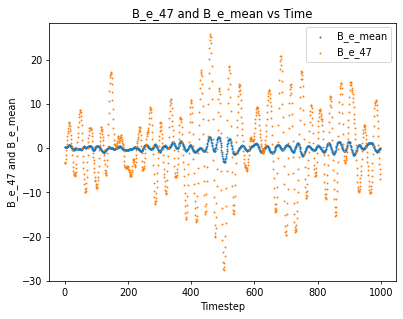

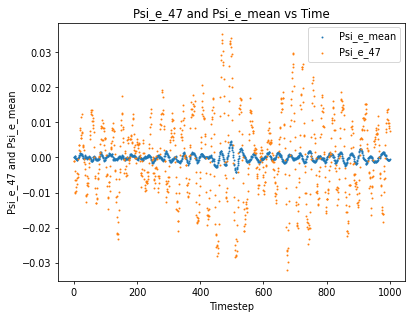

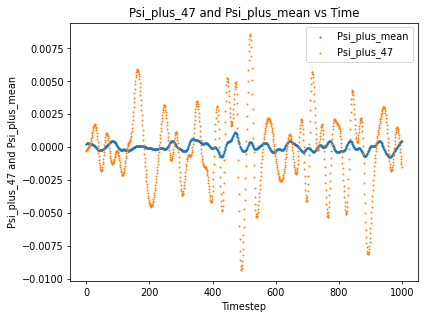

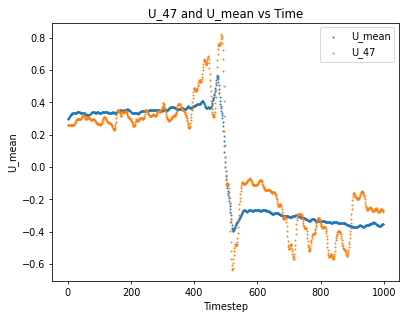

In [37]:
#graphing b_e_means_by_timestep

b_e_array = b_e_arrays[47]

plt.scatter(range(len(b_e_means_by_timestep)), b_e_means_by_timestep, label='B_e_mean', s = 1)
plt.scatter(range(len(b_e_array)), b_e_array, label='B_e_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('B_e_47 and B_e_mean')
plt.title('B_e_47 and B_e_mean vs Time')
plt.legend()

plt.show()

##########
psi_e_array = psi_e_arrays[47]

plt.scatter(range(len(psi_e_means_by_timestep)), psi_e_means_by_timestep, label='Psi_e_mean', s = 1)
plt.scatter(range(len(psi_e_array)), psi_e_array, label='Psi_e_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('Psi_e_47 and Psi_e_mean')
plt.title('Psi_e_47 and Psi_e_mean vs Time')
plt.legend()

plt.show()

##########
psi_plus_array = psi_plus_arrays[47]

plt.scatter(range(len(psi_plus_means_by_timestep)), psi_plus_means_by_timestep, label='Psi_plus_mean', s = 1)
plt.scatter(range(len(psi_plus_array)), psi_plus_array, label='Psi_plus_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('Psi_plus_47 and Psi_plus_mean')
plt.title('Psi_plus_47 and Psi_plus_mean vs Time')
plt.legend()

plt.show()

##########
u_array = u_arrays[47]

plt.scatter(range(len(u_means_by_timestep)), u_means_by_timestep, label='U_mean', s = 1)
plt.scatter(range(len(u_array)), u_array, label='U_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U_mean')
plt.title('U_47 and U_mean vs Time')
plt.legend()

plt.show()


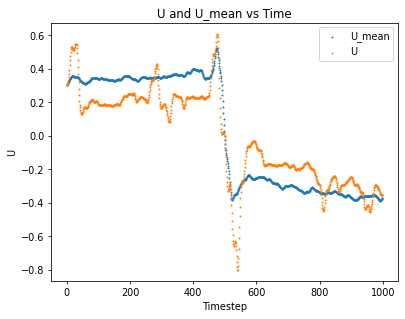

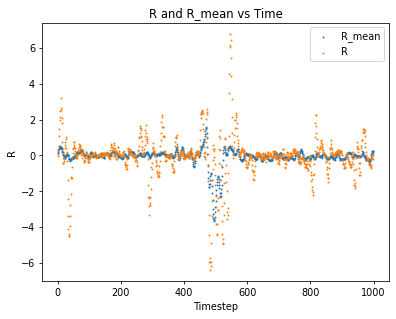

In [36]:
##########
plt.rcParams['figure.dpi'] = 70
c = 41

r_array = r_arrays[c]
u_array2 = u_arrays2[c]

plt.scatter(range(len(u_means_by_timestep2)), u_means_by_timestep2, label='U_mean', s = 1)
plt.scatter(range(len(u_array2)), u_array2, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('U and U_mean vs Time')
plt.legend()

plt.show()

plt.scatter(range(len(r_means_by_timestep)), r_means_by_timestep, label='R_mean', s = 1)
plt.scatter(range(len(r_array)), r_array, label='R', s = 1)
plt.xlabel('Timestep')
plt.ylabel('R')
plt.title('R and R_mean vs Time')
plt.legend()

plt.show()

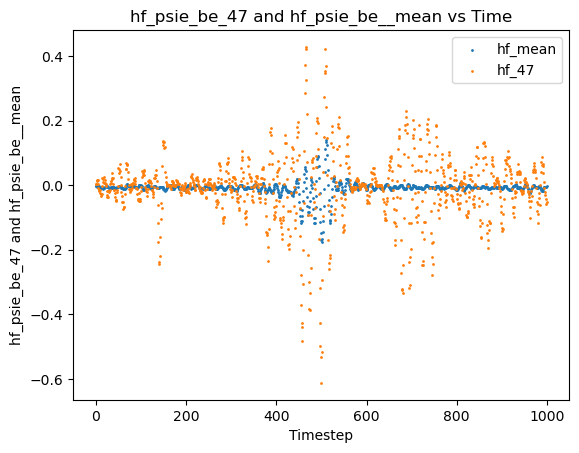

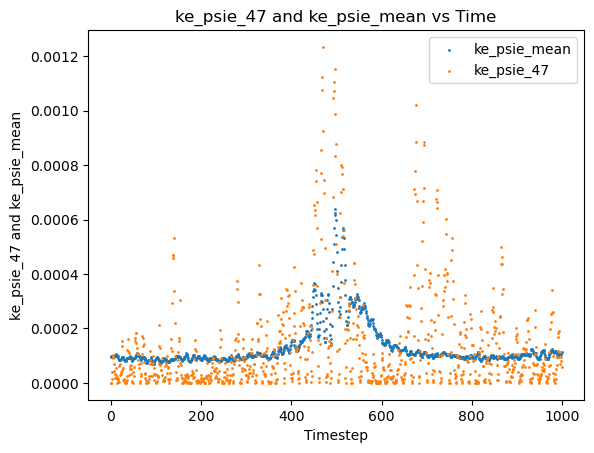

In [ ]:
## Covariance graphing

#####
heat_flux_psi_e_b_e_array = heat_flux_psi_e_b_e_arrays[47]

plt.scatter(range(len(heat_flux_psi_e_b_e_means_by_timestep)), heat_flux_psi_e_b_e_means_by_timestep, label='hf_mean', s = 1)
plt.scatter(range(len(heat_flux_psi_e_b_e_array)), heat_flux_psi_e_b_e_array, label='hf_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('hf_psie_be_47 and hf_psie_be__mean')
plt.title('hf_psie_be_47 and hf_psie_be__mean vs Time')
plt.legend()

plt.show()

#####
k_e_psi_e_array = k_e_psi_e_arrays[47]

plt.scatter(range(len(k_e_psi_e_means_by_timestep)), k_e_psi_e_means_by_timestep, label='ke_psie_mean', s = 1)
plt.scatter(range(len(k_e_psi_e_array)), k_e_psi_e_array, label='ke_psie_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('ke_psie_47 and ke_psie_mean')
plt.title('ke_psie_47 and ke_psie_mean vs Time')
plt.legend()

plt.show()

#####
k_e_psi_e_array = k_e_psi_e_arrays[47]

plt.scatter(range(len(k_e_psi_e_means_by_timestep)), k_e_psi_e_means_by_timestep, label='ke_psie_mean', s = 1)
plt.scatter(range(len(k_e_psi_e_array)), k_e_psi_e_array, label='ke_psie_47', s = 1)
plt.xlabel('Timestep')
plt.ylabel('ke_psie_47 and ke_psie_mean')
plt.title('ke_psie_47 and ke_psie_mean vs Time')
plt.legend()

plt.show()

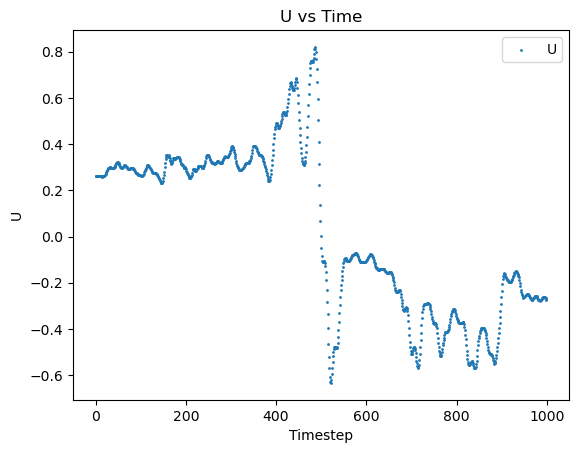

In [79]:
### Let's Graph U for a reversal

u_array = u_arrays[47]

# plotting points as a scatter plot
plt.scatter(range(len(u_array)), u_array, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('U vs Time')
plt.legend()

plt.show()


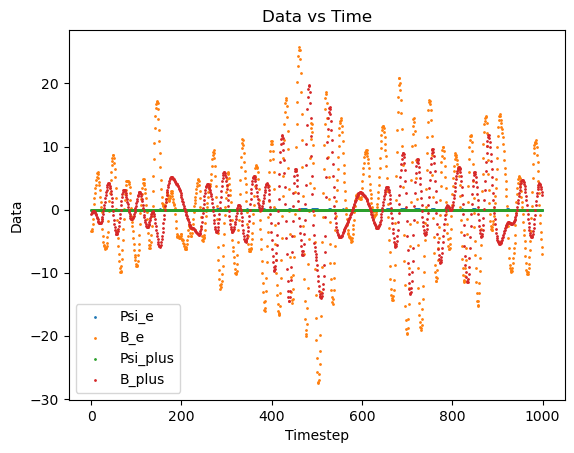

In [19]:
### Let's Graph other data for the same reversal

psi_e_array = psi_e_arrays[47]
b_e_array = b_e_arrays[47]
psi_plus_array = psi_plus_arrays[47]
b_plus_array = b_plus_arrays[47]

# plotting points as a scatter plot
plt.scatter(range(len(psi_e_array)), psi_e_array, label='Psi_e', s = 1)
plt.scatter(range(len(b_e_array)), b_e_array, label='B_e', s = 1)
plt.scatter(range(len(psi_plus_array)), psi_plus_array, label='Psi_plus', s = 1)
plt.scatter(range(len(b_plus_array)), b_plus_array, label='B_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('Data')
plt.title('Data vs Time')
plt.legend()

plt.show()


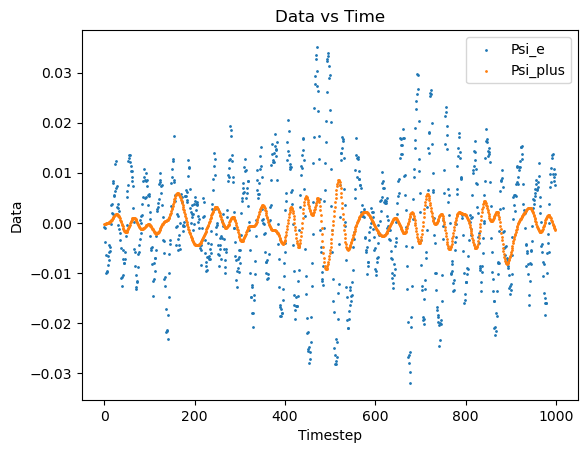

In [20]:
### Let's Graph other data for the same reversal

psi_e_array = psi_e_arrays[47]
psi_plus_array = psi_plus_arrays[47]

# plotting points as a scatter plot
plt.scatter(range(len(psi_e_array)), psi_e_array, label='Psi_e', s = 1)
plt.scatter(range(len(psi_plus_array)), psi_plus_array, label='Psi_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('Data')
plt.title('Data vs Time')
plt.legend()

plt.show()

### Full data graphing

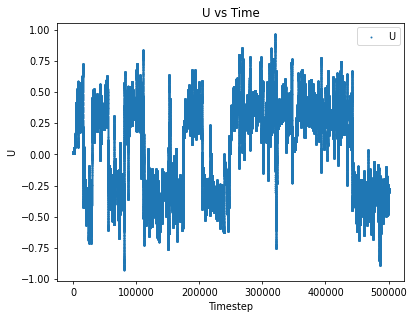

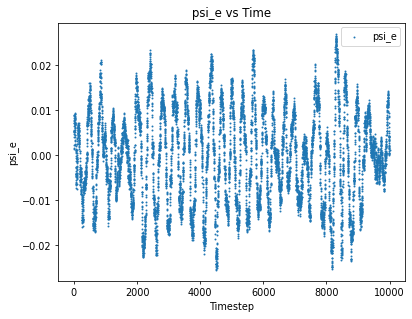

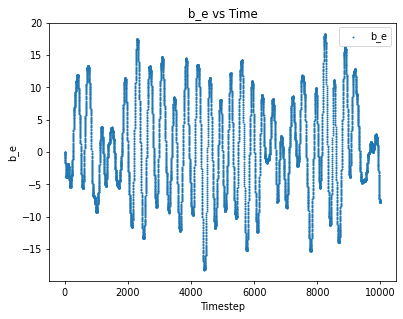

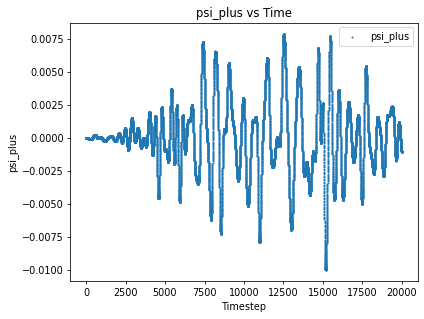

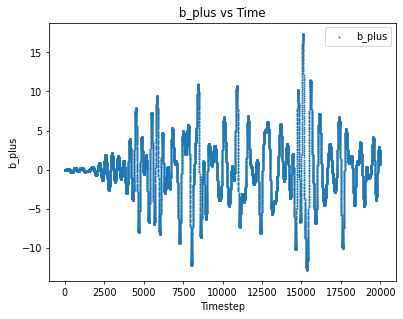

In [45]:
# plotting points as a scatter plot
plt.scatter(range(len(U_full_array)), U_full_array, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('U vs Time')
plt.legend()

plt.show()

# plotting points as a scatter plot
plt.scatter(range(len(psi_e_full_array[0:10000])), psi_e_full_array[0:10000], label='psi_e', s = 1)
plt.xlabel('Timestep')
plt.ylabel('psi_e')
plt.title('psi_e vs Time')
plt.legend()

plt.show()

# plotting points as a scatter plot
plt.scatter(range(len(b_e_full_array[0:10000])), b_e_full_array[0:10000], label='b_e', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_e')
plt.title('b_e vs Time')
plt.legend()

plt.show()


# plotting points as a scatter plot
plt.scatter(range(len(psi_plus_full_array[0:20000])), psi_plus_full_array[0:20000], label='psi_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('psi_plus')
plt.title('psi_plus vs Time')
plt.legend()

plt.show()

# plotting points as a scatter plot
plt.scatter(range(len(b_plus_full_array[0:20000])), b_plus_full_array[0:20000], label='b_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_plus')
plt.title('b_plus vs Time')
plt.legend()

plt.show()

## Changing Initial Conditions

In [67]:
u_zero_full_run = pd.read_csv("full_data_ic_u_as_zero.csv")
high_N_full_run = pd.read_csv("full_data_high_N.csv")
low_N_full_run = pd.read_csv("full_data_low_N.csv")
high_epsilon_full_run = pd.read_csv("full_data_high_epsilon.csv")
low_epsilon_full_run = pd.read_csv("full_data_low_epsilon.csv")

In [57]:
###When initial conditions set U to 0, it cannot change from 0

U_zero_full_array = np.array(u_zero_full_run["u_list"].tolist())
U_zero_full_array = [ast.literal_eval(x) for x in U_zero_full_array]
U_zero_full_array = np.array(U_zero_full_array)[0]

# plotting points as a scatter plot
# plt.scatter(range(len(U_zero_full_array)), U_zero_full_array, label='U', s = 1)
# plt.xlabel('Timestep')
# plt.ylabel('U')
# plt.title('U zero')
# plt.legend()

# plt.show()

### High N

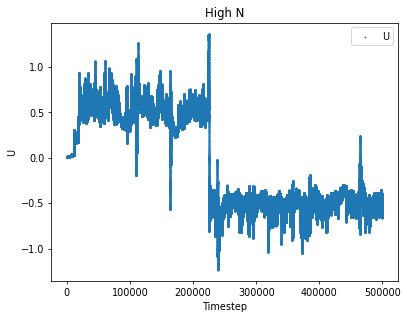

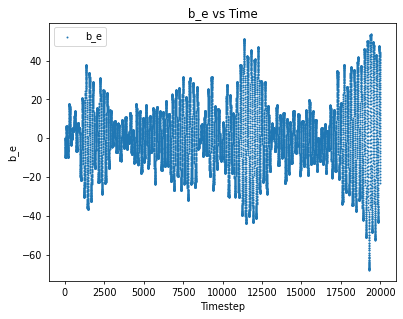

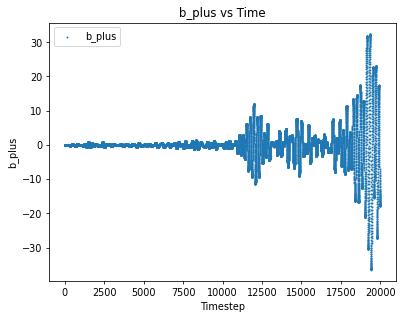

In [ ]:
high_N_full_array = np.array(high_N_full_run["u_list"].tolist())
high_N_full_array = [ast.literal_eval(x) for x in high_N_full_array]
high_N_full_array = np.array(high_N_full_array)[0]

# U
plt.scatter(range(len(high_N_full_array)), high_N_full_array, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('High N')
plt.legend()

plt.show()

# b_e
b_e_full_array2 = high_N_full_run["b_e"].tolist()
b_e_full_array2 = [ast.literal_eval(x) for x in b_e_full_array2]
b_e_full_array2 = np.array(b_e_full_array2)[0]

plt.scatter(range(len(b_e_full_array2[0:20000])), b_e_full_array2[0:20000], label='b_e', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_e')
plt.title('b_e vs Time')
plt.legend()

plt.show()

# b_plus
b_plus_full_array2 = high_N_full_run["b_plus"].tolist()
b_plus_full_array2 = [ast.literal_eval(x) for x in b_plus_full_array2]
b_plus_full_array2 = np.array(b_plus_full_array2)[0]

plt.scatter(range(len(b_plus_full_array2[0:20000])), b_plus_full_array2[0:20000], label='b_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_plus')
plt.title('b_plus vs Time')
plt.legend()

plt.show()

### Low N

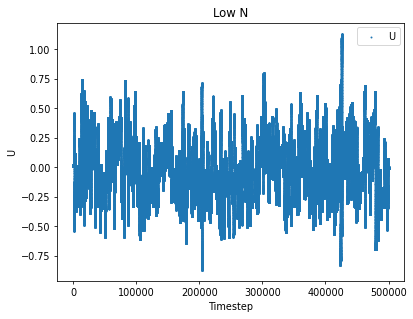

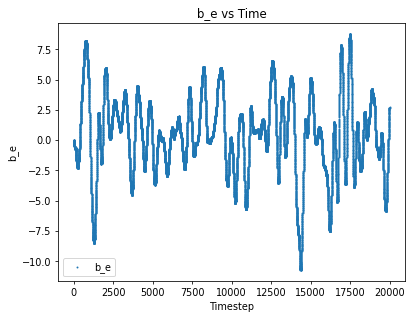

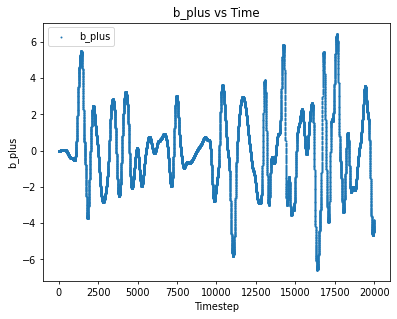

In [63]:
low_N_full_array = np.array(low_N_full_run["u_list"].tolist())
low_N_full_array = [ast.literal_eval(x) for x in low_N_full_array]
low_N_full_array = np.array(low_N_full_array)[0]

# U
plt.scatter(range(len(low_N_full_array)), low_N_full_array, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('Low N')
plt.legend()

plt.show()

# b_e
b_e_full_array3 = low_N_full_run["b_e"].tolist()
b_e_full_array3 = [ast.literal_eval(x) for x in b_e_full_array3]
b_e_full_array3 = np.array(b_e_full_array3)[0]

plt.scatter(range(len(b_e_full_array3[0:20000])), b_e_full_array3[0:20000], label='b_e', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_e')
plt.title('b_e vs Time')
plt.legend()

plt.show()

# b_plus
b_plus_full_array3 = low_N_full_run["b_plus"].tolist()
b_plus_full_array3 = [ast.literal_eval(x) for x in b_plus_full_array3]
b_plus_full_array3 = np.array(b_plus_full_array3)[0]

plt.scatter(range(len(b_plus_full_array3[0:20000])), b_plus_full_array3[0:20000], label='b_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_plus')
plt.title('b_plus vs Time')
plt.legend()

plt.show()

### High Epsilon

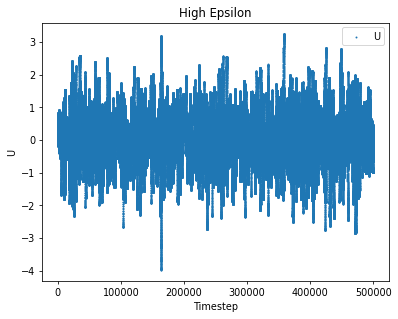

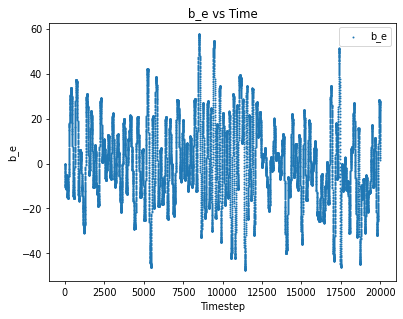

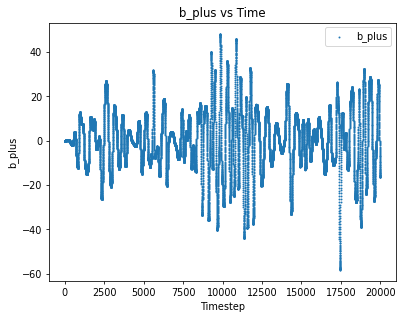

In [ ]:
high_epsilon_full_array = np.array(high_epsilon_full_run["u_list"].tolist())
high_epsilon_full_array = [ast.literal_eval(x) for x in high_epsilon_full_array]
high_epsilon_full_array = np.array(high_epsilon_full_array)[0]

# U
plt.scatter(range(len(high_epsilon_full_array)), high_epsilon_full_array, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('High Epsilon')
plt.legend()

plt.show()

# b_e
b_e_full_array4 = high_epsilon_full_run["b_e"].tolist()
b_e_full_array4 = [ast.literal_eval(x) for x in b_e_full_array4]
b_e_full_array4 = np.array(b_e_full_array4)[0]

plt.scatter(range(len(b_e_full_array4[0:20000])), b_e_full_array4[0:20000], label='b_e', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_e')
plt.title('b_e vs Time')
plt.legend()

plt.show()

# b_plus
b_plus_full_array4 = high_epsilon_full_run["b_plus"].tolist()
b_plus_full_array4 = [ast.literal_eval(x) for x in b_plus_full_array4]
b_plus_full_array4 = np.array(b_plus_full_array4)[0]

plt.scatter(range(len(b_plus_full_array4[0:20000])), b_plus_full_array4[0:20000], label='b_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_plus')
plt.title('b_plus vs Time')
plt.legend()

plt.show()

### Low Epsilon

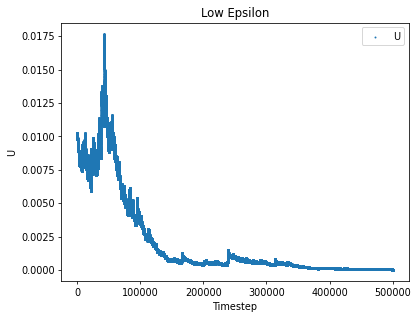

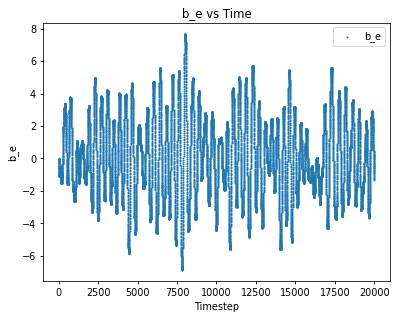

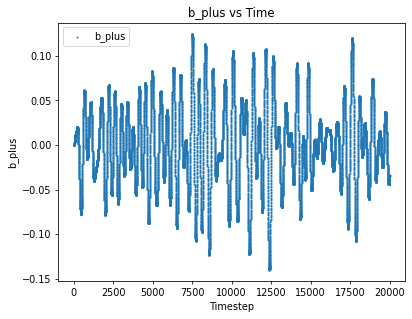

In [68]:
low_epsilon_full_array = np.array(low_epsilon_full_run["u_list"].tolist())
low_epsilon_full_array = [ast.literal_eval(x) for x in low_epsilon_full_array]
low_epsilon_full_array = np.array(low_epsilon_full_array)[0]

# U
plt.scatter(range(len(low_epsilon_full_array)), low_epsilon_full_array, label='U', s = 1)
plt.xlabel('Timestep')
plt.ylabel('U')
plt.title('Low Epsilon')
plt.legend()

plt.show()

# b_e
b_e_full_array5 = low_epsilon_full_run["b_e"].tolist()
b_e_full_array5 = [ast.literal_eval(x) for x in b_e_full_array5]
b_e_full_array5 = np.array(b_e_full_array5)[0]

plt.scatter(range(len(b_e_full_array5[0:20000])), b_e_full_array5[0:20000], label='b_e', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_e')
plt.title('b_e vs Time')
plt.legend()

plt.show()

# b_plus
b_plus_full_array5 = low_epsilon_full_run["b_plus"].tolist()
b_plus_full_array5 = [ast.literal_eval(x) for x in b_plus_full_array5]
b_plus_full_array5 = np.array(b_plus_full_array5)[0]

plt.scatter(range(len(b_plus_full_array5[0:20000])), b_plus_full_array5[0:20000], label='b_plus', s = 1)
plt.xlabel('Timestep')
plt.ylabel('b_plus')
plt.title('b_plus vs Time')
plt.legend()

plt.show()